In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import sklearn.datasets

In [2]:
def get_iris_df():
    ds = sklearn.datasets.load_iris()
    df = pd.DataFrame(ds["data"], columns=ds["feature_names"])
    code_species_map = dict(zip(range(3), ds['target_names']))
    df['species'] = [code_species_map[c] for c in ds['target']]
    return df

In [3]:
df = get_iris_df()
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


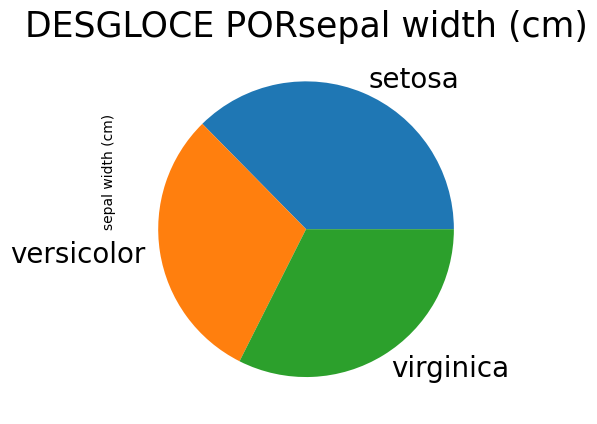

In [4]:
sums_by_species = df.groupby('species').sum()
var = 'sepal width (cm)'
sums_by_species[var].plot(kind='pie', fontsize=20)
plt.ylabel(var, horizontalalignment='left')
plt.title('DESGLOCE POR' + var, fontsize=25)
plt.show()
plt.savefig('grafico_sectores_iris_una_variable.jpg')
plt.close()

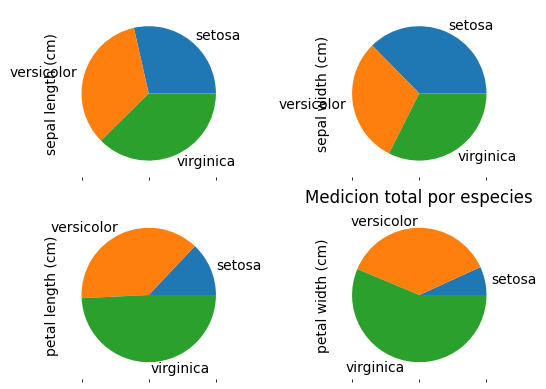

In [5]:
sums_by_species = df.groupby('species').sum()
sums_by_species.plot(kind='pie', subplots= True, layout= (2,2), legend=False)
plt.title('Medicion total por especies')
plt.show()

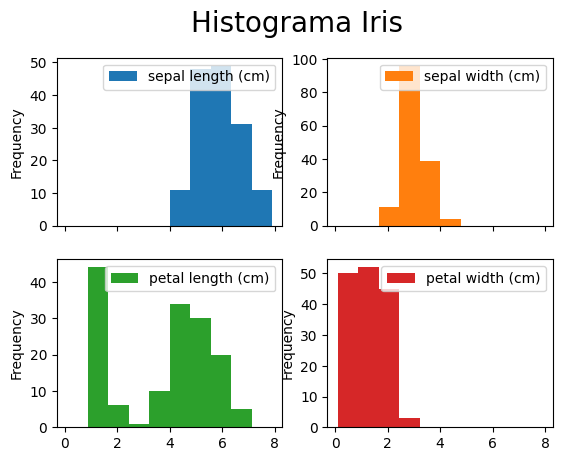

In [6]:
df.plot(kind='hist', subplots=True, layout=(2,2))
plt.suptitle('Histograma Iris', fontsize=20)
plt.show()

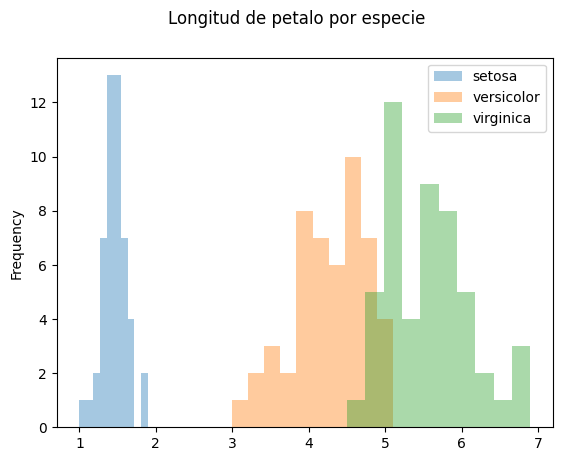

In [7]:
for spec in df['species'].unique():
    forspec = df[df['species'] == spec]
    forspec['petal length (cm)'].plot(kind='hist', alpha=0.4, label=spec)
plt.legend(loc='upper right')
plt.suptitle('Longitud de petalo por especie')
plt.show()

In [8]:
col = df['petal length (cm)']
promedio = col.mean()
std = col.std()
#mediana = col.median()
mediana = col.quantile(0.5)
percentil25=col.quantile(0.25) # Cuartil 1
percentil75 = col.quantile(0.75) # Cuartil 3
print('Promedio: ', promedio)
print('Desviacion Estandar:', std)
print('Mediana: ', mediana)
print('Percentil 25:', percentil25)
print('Percentil 75: ', percentil75)

Promedio:  3.7580000000000005
Desviacion Estandar: 1.7652982332594662
Mediana:  4.35
Percentil 25: 1.6
Percentil 75:  5.1


In [9]:
col = df['petal length (cm)']
percentil25=col.quantile(0.25) # Cuartil 1
percentil75 = col.quantile(0.75) # Cuartil 3
media_limpia = col[(col>percentil25) & (col< percentil75)].mean()

print('Promedio: ', promedio)
print('Promedio limpio:', media_limpia)

Promedio:  3.7580000000000005
Promedio limpio: 4.0984375


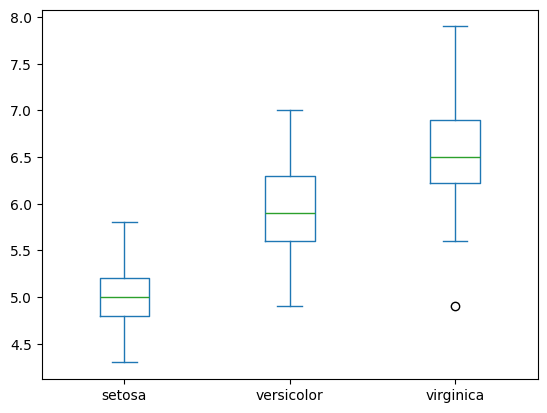

In [10]:
col = "sepal length (cm)"
df["ind"] = pd.Series(df.index).apply(lambda i: i%50)
df.pivot(index= "ind", columns= "species")[col].plot(kind="box")
plt.show()

In [11]:
col = "sepal length (cm)"
df["ind"] = pd.Series(df.index).apply(lambda i: i%50)
df.pivot(index= "ind", columns= "species")

sepal length (cm)                      sepal width (cm)             \
species            setosa versicolor virginica           setosa versicolor   
ind                                                                          
0                     5.1        7.0       6.3              3.5        3.2   
1                     4.9        6.4       5.8              3.0        3.2   
2                     4.7        6.9       7.1              3.2        3.1   
3                     4.6        5.5       6.3              3.1        2.3   
4                     5.0        6.5       6.5              3.6        2.8   
5                     5.4        5.7       7.6              3.9        2.8   
6                     4.6        6.3       4.9              3.4        3.3   
7                     5.0        4.9       7.3              3.4        2.4   
8                     4.4        6.6       6.7              2.9        2.9   
9                     4.9        5.2       7.2              3.1        2.7   
10                    5.4        5.0       6.5              3.7        2.0   
11                    4.8        5.9       6.4              3.4        3.0   
12                    4.8        6.0       6.8              3.0        2.2   
13                    4.3        6.1       5.7              3.0        2.9   
14                    5.8        5.6       5.8              4.0        2.9   
15                    5.7        6.7       6.4              4.4        3.1   
16                    5.4        5.6       6.5              3.9        3.0   
17                    5.1        5.8       7.7              3.5        2.7   
18                    5.7        6.2       7.7              3.8        2.2   
19                    5.1        5.6       6.0              3.8        2.5   
20                    5.4        5.9       6.9              3.4        3.2   
21                    5.1        6.1       5.6              3.7        2.8   
22                    4.6        6.3       7.7              3.6        2.5   
23                    5.1        6.1       6.3              3.3        2.8   
24                    4.8        6.4       6.7              3.4        2.9   
25                    5.0        6.6       7.2              3.0        3.0   
26                    5.0        6.8       6.2              3.4        2.8   
27                    5.2        6.7       6.1              3.5        3.0   
28                    5.2        6.0       6.4              3.4        2.9   
29                    4.7        5.7       7.2              3.2        2.6   
30                    4.8        5.5       7.4              3.1        2.4   
31                    5.4        5.5       7.9              3.4        2.4   
32                    5.2        5.8       6.4              4.1        2.7   
33                    5.5        6.0       6.3              4.2        2.7   
34                    4.9        5.4       6.1              3.1        3.0   
35                    5.0        6.0       7.7              3.2        3.4   
36                    5.5        6.7       6.3              3.5        3.1   
37                    4.9        6.3       6.4              3.6        2.3   
38                    4.4        5.6       6.0              3.0        3.0   
39                    5.1        5.5       6.9              3.4        2.5   
40                    5.0        5.5       6.7              3.5        2.6   
41                    4.5        6.1       6.9              2.3        3.0   
42                    4.4        5.8       5.8              3.2        2.6   
43                    5.0        5.0       6.8              3.5        2.3   
44                    5.1        5.6       6.7              3.8        2.7   
45                    4.8        5.7       6.7              3.0        3.0   
46                    5.1        5.7       6.3              3.8        2.9   
47                    4.6        6.2       6.5              3.2        2.9   
48                    5.3     

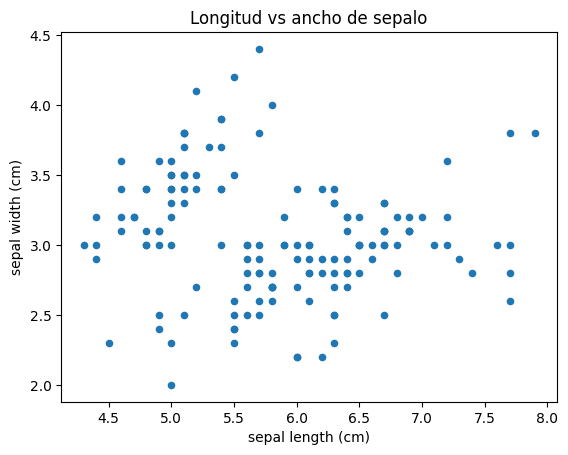

In [12]:
df.plot(kind="scatter", x= "sepal length (cm)", y = "sepal width (cm)")
plt.title("Longitud vs ancho de sepalo")
plt.show()

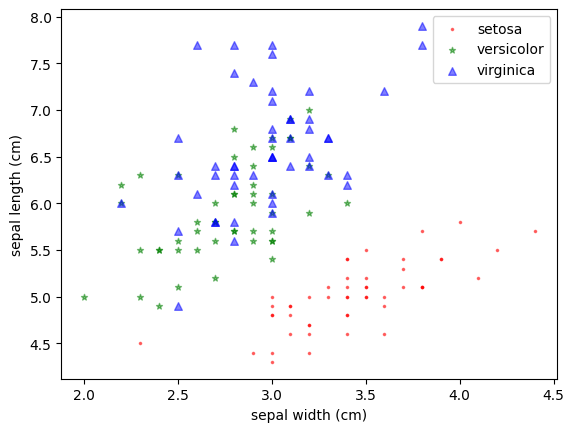

In [13]:
colors = ["r", "g", "b"]
markers = [".", "*", "^"]
fig, ax1 = plt.subplots(1,1)
for i, spec in enumerate(df["species"].unique()):
    ddf = df[df["species"]==spec]
    ddf.plot(kind="scatter", x="sepal width (cm)", y="sepal length (cm)", alpha=0.5, s=10*(i+1), ax=ax1, color=colors[i], marker=markers[i], label = spec)
plt.legend()
plt.show()

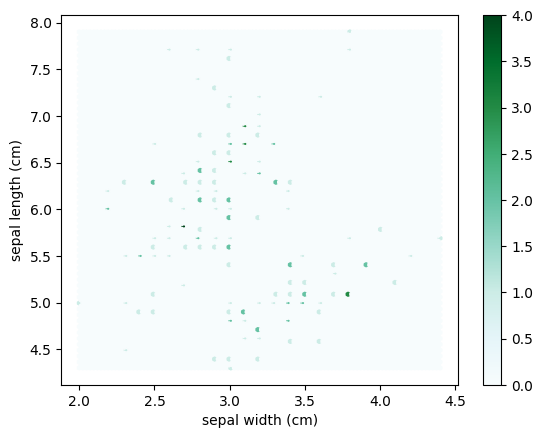

In [14]:
df.plot(kind = "hexbin", x = "sepal width (cm)", y = "sepal length (cm)")
plt.show()

In [19]:
print(df["sepal width (cm)"].corr(df["sepal length (cm)"]))
df["sepal width (cm)"].corr(df["sepal length (cm)"], method="pearson")
df["sepal width (cm)"].corr(df["sepal length (cm)"], method="kendall")
df["sepal width (cm)"].corr(df["sepal length (cm)"], method="spearman")

-0.11756978413300208


-0.166777658283235